Plots for epednn_multieq_profilesloop.py runs

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from scipy.interpolate import interp1d
from pathlib import Path

In [2]:
from matplotlib import font_manager
FontSize = 16
label_kw = {"fontsize": FontSize}
tick_labelsize = FontSize - 4

plt.rcParams.update(
    {
        "figure.figsize": (6.4, 4.8)
    }
)

In [3]:
# Inputs
out_dir = 'multiequil_PTHmode_Snyder_bcig/'

In [4]:
def read_pfile(path):
    data = {}
    key = ''
    with open(path) as f:
        for line in f:
            if '3 N Z A' in line:
                break
            if line.startswith('201'):
                key = line.split()[2]
                data[key] = np.array([])
                data[f'{key}_psi'] = np.array([])
            else:
                psi, dat, _ = line.split()
                psi = float(psi)
                dat = float(dat)
                data[key] = np.append(data[key], dat)
                data[f'{key}_psi'] = np.append(data[f'{key}_psi'], psi)
    return data

In [5]:
def OMFITnc_load(filename):
    """
    Reads an OMFITnc file, averages kinetic profiles across the first dimension,
    and interpolates them onto a common, unified psi_N grid.

    Parameters:
        filename (str): Path to the NetCDF file.

    Returns:
        tuple: (psi_N_unified, Te_1d, ne_1d, p_ion_1d) as 1D numpy arrays.
        Te_1d in keV, ne_1d in m^-3, p_ion_1d in Pa.

    Notes:
        IDA OMFITnc files typically lack T_i / n_i. Ion pressure is taken from
        p_ion when present (checked O(1) vs pe = ne*Te*e); otherwise pe is used.

    # Example usage:
    # psi_grid, Te, ne, p_ion = OMFITnc_load('my_plasma_data.cdf')
    """
    from omfit_classes.omfit_nc import OMFITnc
    nc = OMFITnc(filename)
    e_charge = 1.602176634e-19  # C

    def _nc_array(var_name):
        """OMFITnc variables are SortedDicts; numeric data lives under 'data'."""
        var = nc[var_name]
        if hasattr(var, 'keys') and 'data' in var:
            return np.asarray(var['data'], dtype=float)
        return np.asarray(var, dtype=float)

    def _nc_has(var_name):
        return var_name in nc

    def _reduce_time(arr):
        """Average over a leading time axis if present."""
        arr = np.asarray(arr, dtype=float)
        if arr.ndim > 1:
            return np.mean(arr, axis=0)
        return arr

    # 1. Extract and average electron profiles
    Te_raw = _reduce_time(_nc_array('T_e'))
    ne_raw = _reduce_time(_nc_array('n_e'))

    # Convert Te to keV if the file stores eV (IDA OMFITnc files use eV)
    te_unit = ''
    if hasattr(nc['T_e'], 'keys') and 'unit' in nc['T_e']:
        te_unit = str(nc['T_e']['unit']).lower()
    if te_unit in ('ev', 'electron volt', 'electron-volt'):
        Te_raw = Te_raw / 1e3
    elif te_unit in ('kev',):
        pass
    elif np.nanmax(np.abs(Te_raw)) > 100:
        # Heuristic: values >> 100 are almost certainly eV, not keV
        Te_raw = Te_raw / 1e3

    # 2. Ion pressure from file if present; else fall back to pe after interpolation
    has_p_ion = _nc_has('p_ion')
    if has_p_ion:
        p_ion_raw = _reduce_time(_nc_array('p_ion'))  # Pa
    else:
        print(
            f"No p_ion found in {filename}. "
            f"Available keys: {[k for k in nc.keys() if not str(k).startswith('__')]}"
        )
        print('Using pe = ne*Te*e as p_ion')
        p_ion_raw = None

    # 3. Determine psi_N grids (files may use psi_n / psi_N / separate Te,ne grids)
    if _nc_has('psi_N_Te') and _nc_has('psi_N_ne'):
        psi_Te = _reduce_time(_nc_array('psi_N_Te'))
        psi_ne = _reduce_time(_nc_array('psi_N_ne'))
        psi_ion = (
            _reduce_time(_nc_array('psi_N_ion'))
            if _nc_has('psi_N_ion')
            else psi_ne
        )
    else:
        for psi_key in ('psi_n', 'psi_N', 'psiN', 'psin'):
            if _nc_has(psi_key):
                break
        else:
            raise KeyError(
                f"No psi_N grid found in {filename}. "
                f"Available keys: {[k for k in nc.keys() if not str(k).startswith('__')]}"
            )
        psi_shared = _reduce_time(_nc_array(psi_key))
        psi_Te = psi_ne = psi_ion = psi_shared

    # Keep only the closed-flux domain for interpolation onto [0, 1]
    def _clip_profile(psi, prof):
        psi = np.asarray(psi, dtype=float).ravel()
        prof = np.asarray(prof, dtype=float).ravel()
        order = np.argsort(psi)
        psi, prof = psi[order], prof[order]
        mask = (psi >= 0.0) & (psi <= 1.0)
        if np.count_nonzero(mask) < 2:
            mask = np.ones_like(psi, dtype=bool)
        # Drop duplicate psi points that break interp1d
        _, uniq = np.unique(psi[mask], return_index=True)
        uniq = np.sort(uniq)
        return psi[mask][uniq], prof[mask][uniq]

    psi_Te, Te_raw = _clip_profile(psi_Te, Te_raw)
    psi_ne, ne_raw = _clip_profile(psi_ne, ne_raw)
    if has_p_ion:
        psi_ion, p_ion_raw = _clip_profile(psi_ion, p_ion_raw)
        num_points = max(len(psi_Te), len(psi_ne), len(psi_ion))
    else:
        num_points = max(len(psi_Te), len(psi_ne))

    # 4. Unified evaluation grid on [0, 1]
    psi_N_unified = np.linspace(0.0, 1.0, num_points)

    # 5. Interpolate profiles onto the unified grid
    Te_unified = interp1d(
        psi_Te, Te_raw, kind='cubic', bounds_error=False, fill_value='extrapolate'
    )(psi_N_unified)
    ne_unified = interp1d(
        psi_ne, ne_raw, kind='cubic', bounds_error=False, fill_value='extrapolate'
    )(psi_N_unified)

    pe_unified = ne_unified * (Te_unified * 1e3) * e_charge  # Pa
    if has_p_ion:
        p_ion_unified = interp1d(
            psi_ion, p_ion_raw, kind='cubic', bounds_error=False, fill_value='extrapolate'
        )(psi_N_unified)
        # Sanity check: p_ion should be O(1) times electron pressure
        ratio_med = float(np.nanmedian(p_ion_unified / pe_unified))
        if not (0.3 < ratio_med < 5.0):
            raise ValueError(
                f"p_ion does not look like ion pressure in {filename}: "
                f"median(p_ion / (ne*Te*e)) = {ratio_med:.3g} (expected O(1))"
            )
    else:
        p_ion_unified = pe_unified

    return psi_N_unified, Te_unified, ne_unified, p_ion_unified


No p_ion found in /mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode/IDA_125732_3.45_3.55_.cdf. Available keys: ['amin_midplane', 'amin_midplane_err', 'Bpol_midplane', 'Bpol_midplane_err', 'dlog_ne_dpsin', 'dlog_ne_dpsin_err', 'dlog_Te_dpsin', 'dlog_Te_dpsin_err', 'dPsiN_dR_midplane', 'dPsiN_dR_midplane_err', 'n_e', 'n_e_err', 'psi_axis', 'psi_n', 'psi_sep', 'q', 'q_err', 'rho_tor', 'rho_tor_err', 'Rmaj_midplane', 'Rmaj_midplane_err', 'T_e', 'T_e_err', 'time']
Using pe = ne*Te*e as p_ion
No p_ion found in /mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode/IDA_128578_3.6_3.7_.cdf. Available keys: ['amin_midplane', 'amin_midplane_err', 'Bpol_midplane', 'Bpol_midplane_err', 'dlog_ne_dpsin', 'dlog_ne_dpsin_err', 'dlog_Te_dpsin', 'dlog_Te_dpsin_err', 'dPsiN_dR_midplane', 'dPsiN_dR_midplane_err', 'n_e', 'n_e_err', 'psi_axis', 'psi_n', 'psi_sep', 'q', 'q_err', 'rho_tor', 'rho_tor_err', 'Rmaj_midplane', 'Rmaj_midplane_err', 'T_e', 'T_e_err', 'time']
Using pe = n

(0.0, 21.0)

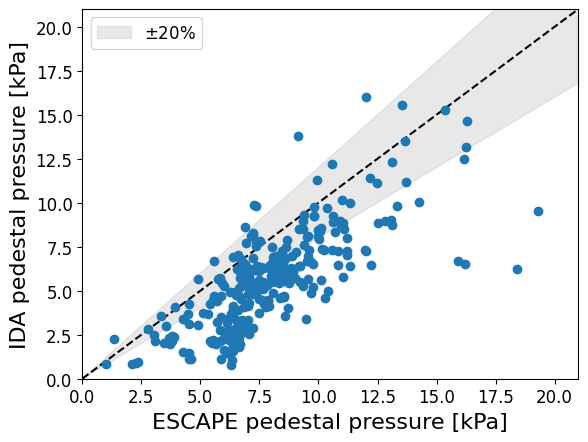

In [6]:
# For the successful equilibria, plot the predicted pressure vs. geqdsk pressure at psiN=1-delta and psiN=0.85
fig, ax = plt.subplots()
i=0
for entry in Path(out_dir).iterdir():

    target = entry/'success_outdict.npy'
    if target.exists():
        out_dict = np.load(target, allow_pickle=True).item()
        i+=1
    else: 
        continue


    if out_dict['kprof_fp'].endswith('.cdf'):
        # print(out_dict['kprof_fp'])
        psi_N_unified, Te_unified, ne_unified, p_ion_unified = OMFITnc_load(
            out_dict['kprof_fp']
        )

        # Total kinetic pressure at ped top: pe + p_ion [Pa]
        Te_ped = np.interp(1 - out_dict['ped_wid'], psi_N_unified, Te_unified)  # keV
        ne_ped = np.interp(1 - out_dict['ped_wid'], psi_N_unified, ne_unified)  # m^-3
        p_ion_ped = np.interp(1 - out_dict['ped_wid'], psi_N_unified, p_ion_unified)
        p_ped_h = ne_ped * (Te_ped * 1e3) * 1.602176634e-19 + p_ion_ped

    else: # assumes pfile
        pf = read_pfile(out_dict['kprof_fp'])

        # Store pfile information
        T_e_pfile = pf['te(KeV)'] # T_e values (keV) evaluated at psi_Te_eval
        psi_Te_eval_pfile = pf['te(KeV)_psi'] # psi_N values at which T_e is evaluated

        n_e_pfile = pf['ne(10^20/m^3)'] * 1e20 # n_e values (10^20/m^3 -> m^-3) evaluated at psi_ne_eval
        psi_ne_eval = pf['ne(10^20/m^3)_psi'] # psi_N values at which n_e is evaluated

        T_i_pfile = pf['ti(KeV)'] # T_e values (keV) evaluated at psi_Te_eval
        psi_Ti_eval_pfile = pf['ti(KeV)_psi'] # psi_N values at which T_e is evaluated

        n_i_pfile = pf['ni(10^20/m^3)'] * 1e20 # n_e values (10^20/m^3 -> m^-3) evaluated at psi_ne_eval
        psi_ni_eval = pf['ni(10^20/m^3)_psi'] # psi_N values at which n_e is evaluated

        # "Correct" pressure: pfile total pressure at ped [Pa]
        T_e_ped = np.interp(1-out_dict['ped_wid'], psi_Te_eval_pfile, T_e_pfile) * 1e3  # keV -> eV
        n_e_ped = np.interp(1-out_dict['ped_wid'], psi_ne_eval, n_e_pfile)
        T_i_ped = np.interp(1-out_dict['ped_wid'], psi_Ti_eval_pfile, T_i_pfile) * 1e3  # keV -> eV
        n_i_ped = np.interp(1-out_dict['ped_wid'], psi_ni_eval, n_i_pfile)
        p_ped_h = (n_e_ped * T_e_ped + n_i_ped * T_i_ped) * 1.602176634e-19
    
    ax.plot(out_dict['ped_h']*1e3,p_ped_h / 1e3,'o',color='tab:blue')

x_line = np.linspace(0, 0.03 * 10**3, 200)
pm = 20
ax.fill_between(
    x_line, (1-(pm/100)) * x_line, (1+(pm/100)) * x_line,
    color='0.75', alpha=0.35, label=f'$\pm {pm}\\%$',
    zorder=0,
)
ax.plot(x_line, x_line, 'k--', zorder=1)
ax.set_ylabel('IDA pedestal pressure [kPa]', **label_kw)
ax.set_xlabel('ESCAPE pedestal pressure [kPa]', **label_kw)
ax.legend(loc='upper left', fontsize=tick_labelsize)
ax.tick_params('both', labelsize=tick_labelsize)
ax.set_xlim(0, 0.021 * 10**3)
ax.set_ylim(0, 0.021 * 10**3)

In [7]:
print('Successful runs:', i)

Successful runs: 302


(0.0, 21.0)

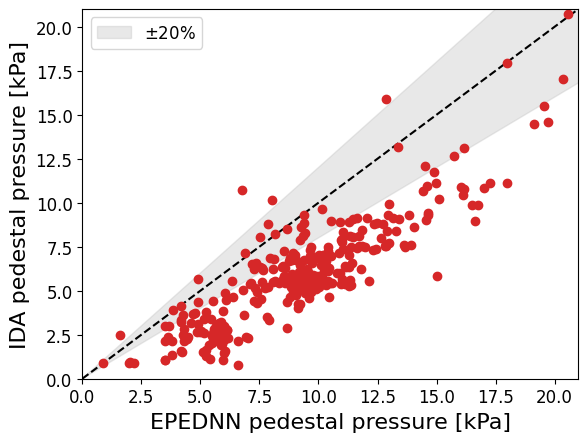

In [8]:
# For the successful equilibria, plot the predicted pressure vs. geqdsk pressure at psiN=1-delta and psiN=0.85
out_dir_EPEDNN_pure = '/mnt/homes_global/jal2351/software/saarelma-conner-ped/tests/EPEDNN/EPEDNN_pure_output/'

fig, ax = plt.subplots()
j=0
for entry in Path(out_dir_EPEDNN_pure).iterdir():

    if entry.exists():
        out_dict = np.load(entry, allow_pickle=True).item()
        j+=1
    else: 
        continue

    kfile_pres = out_dict['kfile_pres']
    psiN_kfilepres = out_dict['psiN_kfilepres']
    psiN_ped_kfile = 1 - out_dict['pedestal_width']
    pres_h_pred = out_dict['pedestal_height'] # from EPEDNN
    p_ped_kfile = np.interp(psiN_ped_kfile, psiN_kfilepres, kfile_pres) # from kinetic profiles
    ax.plot(pres_h_pred * 1e3, p_ped_kfile / 1e3, 'o',color='tab:red') # kPa

x_line = np.linspace(0, 0.03 * 10**3, 200)
pm = 20
ax.fill_between(
    x_line, (1-(pm/100)) * x_line, (1+(pm/100)) * x_line,
    color='0.75', alpha=0.35, label=f'$\pm {pm}\\%$',
    zorder=0,
)
ax.plot(x_line, x_line, 'k--', zorder=1)
ax.set_ylabel('IDA pedestal pressure [kPa]', **label_kw)
ax.set_xlabel('EPEDNN pedestal pressure [kPa]', **label_kw)
# ax.set_title('EPEDNN Only')
ax.legend(loc='upper left', fontsize=tick_labelsize)
ax.tick_params('both', labelsize=tick_labelsize)
ax.set_xlim(0, 0.021 * 10**3)
ax.set_ylim(0, 0.021 * 10**3)

In [9]:
print('Successful runs:', j)

Successful runs: 302


In [10]:
# Pedestal top from sc_inputs/run_fit_pedestals.py (p_tot, gradient method).
# Use these for:
#   - psiN location at which to sample IDA pressure (y-axis)
#   - optional: grad_ped_val = IDA p_tot already evaluated at that location
import csv
from collections import defaultdict

PED_TOP_CSV = (
    '/mnt/homes_global/jal2351/software/sc_inputs/'
    'pedestal_tops_summary_HighPerfHMode.csv'
)
PED_FITS_CSV = (
    '/mnt/homes_global/jal2351/software/sc_inputs/'
    'pedestal_fits_HighPerfHMode.csv'
)

# shot -> list of time-slice fit results
ped_top_by_shot = defaultdict(list)
with open(PED_TOP_CSV) as f:
    for row in csv.DictReader(f):
        if row.get('bad') in ('1', 'True', 'true'):
            continue
        if not row.get('ped_top_grad'):
            continue
        ped_top_by_shot[int(row['shot'])].append({
            'time_ms': float(row['time_ms']),
            'ped_top_grad': float(row['ped_top_grad']),   # sym - width/2  (preferred)
            'ped_top_1mw': float(row['ped_top_1mw']),     # 1 - grad_width
            'grad_width': float(row['grad_width']),
            'status': row['status'],
        })

# Also load grad_ped_val (Pa) from the full fits CSV — this IS the IDA p_tot
# at the fit pedestal top, so the y-axis does not need re-interpolation.
ped_val_by_shot = defaultdict(list)
with open(PED_FITS_CSV) as f:
    for row in csv.DictReader(f):
        if row.get('profile') != 'p_tot' or not row.get('grad_ped_val'):
            continue
        try:
            ped_val_by_shot[int(row['shot'])].append({
                'time_ms': float(row['time']),
                'grad_ped_val': float(row['grad_ped_val']),  # Pa
                'ped_eval_psin': float(row['ped_eval_psin']) if row['ped_eval_psin'] else np.nan,
            })
        except ValueError:
            continue

def _nearest(rows, time_ms):
    return min(rows, key=lambda r: abs(r['time_ms'] - time_ms))

def ped_top_for_tag(equil_tag, prefer='ped_top_grad'):
    """Map equil tag '125729.03589' -> nearest fit_pedestals ped-top psiN."""
    shot_s, time_s = equil_tag.split('.', 1)
    shot = int(shot_s)
    time_ms = float(time_s)  # e.g. '03589' -> 3589 ms
    rows = ped_top_by_shot.get(shot)
    if not rows:
        return None
    return _nearest(rows, time_ms)[prefer]

def ped_val_for_tag(equil_tag):
    """IDA p_tot [Pa] at fit ped-top for equil tag (from fit_pedestals grad method)."""
    shot_s, time_s = equil_tag.split('.', 1)
    shot = int(shot_s)
    time_ms = float(time_s)
    rows = ped_val_by_shot.get(shot)
    if not rows:
        return None
    return _nearest(rows, time_ms)['grad_ped_val']

print(f'Loaded ped-top fits for {len(ped_top_by_shot)} shots '
      f'({sum(len(v) for v in ped_top_by_shot.values())} time slices)')
print(f'Loaded grad_ped_val for {len(ped_val_by_shot)} shots')


Loaded ped-top fits for 214 shots (906 time slices)
Loaded grad_ped_val for 214 shots


Plotted 302 ESCAPE successes (skipped 0 without ped-top fit)


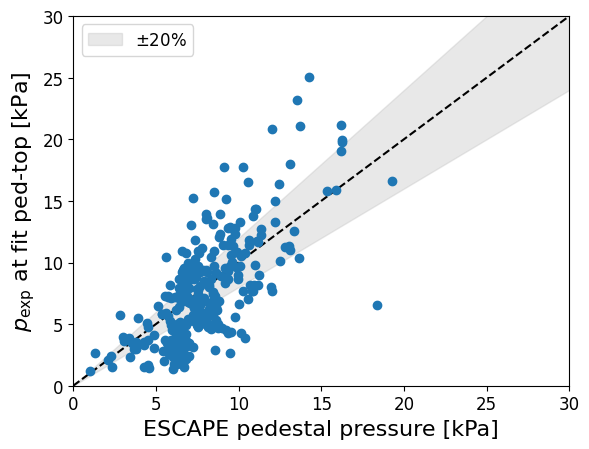

In [15]:
# ESCAPE (x) vs IDA p at fit_pedestals ped-top (y).
# y uses grad_ped_val from the single nearest time slice (same as the EPEDNN plot cell).
fig, ax = plt.subplots()
i_fit = 0
n_skip_fit = 0
for entry in Path(out_dir).iterdir():
    target = entry / 'success_outdict.npy'
    if not target.exists():
        continue
    out_dict = np.load(target, allow_pickle=True).item()

    p_ped_ida = ped_val_for_tag(entry.name)  # Pa, single time-slice at fit ped-top
    if p_ped_ida is None or not np.isfinite(p_ped_ida):
        n_skip_fit += 1
        continue

    ax.plot(out_dict['ped_h'] * 1e3, p_ped_ida / 1e3, 'o', color='tab:blue')  # kPa
    i_fit += 1

x_line = np.linspace(0, 0.03 * 10**3, 200)
pm = 20
ax.fill_between(
    x_line, (1 - (pm / 100)) * x_line, (1 + (pm / 100)) * x_line,
    color='0.75', alpha=0.35, label=fr'$\pm {pm}\%$',
    zorder=0,
)
ax.plot(x_line, x_line, 'k--', zorder=1)
ax.set_ylabel(r'$p_{\mathrm{exp}}$ at fit ped-top [kPa]', **label_kw)
ax.set_xlabel('ESCAPE pedestal pressure [kPa]', **label_kw)
ax.legend(loc='upper left', fontsize=tick_labelsize)
ax.tick_params('both', labelsize=tick_labelsize)
ax.set_xlim(0, 0.03 * 10**3)
ax.set_ylim(0, 0.03 * 10**3)
print(f'Plotted {i_fit} ESCAPE successes (skipped {n_skip_fit} without ped-top fit)')


Plotted 302 EPEDNN-pure cases (skipped 0 without ped-top fit)
If points sit systematically off the diagonal, re-run epednn_pure.py (Zeff + ne@ped_top fixes).


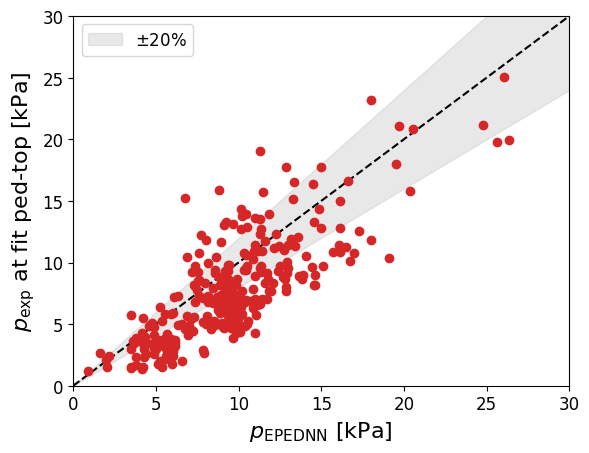

In [14]:
# EPEDNN (x) vs IDA p at fit_pedestals ped-top (y).
#
# IMPORTANT: the existing EPEDNN_pure_output/ was generated with two input bugs
# in epednn_pure.py (now fixed):
#   1) zeffped hardcoded to Z_i=1  (IDA ped Zeff is ~1.7)
#   2) ne_ped sampled at fixed psiN=0.95 instead of the fit ped-top
# Re-run epednn_pure.py before expecting agreement like the reference figure.
#
# y uses grad_ped_val from fit_pedestals (IDA p_tot at ped_top_grad) — do NOT
# evaluate at 1 - EPEDNN_width (that was the old cell-8 bug).
out_dir_EPEDNN_pure = (
    '/mnt/homes_global/jal2351/software/saarelma-conner-ped/tests/EPEDNN/'
    'EPEDNN_pure_output/'
)

fig, ax = plt.subplots()
j_fit = 0
n_skip_eped = 0
for entry in Path(out_dir_EPEDNN_pure).iterdir():
    if not entry.exists() or entry.suffix != '.npy':
        continue
    out_dict = np.load(entry, allow_pickle=True).item()

    p_ped_ida = ped_val_for_tag(entry.stem)  # Pa, at fit ped-top
    if p_ped_ida is None or not np.isfinite(p_ped_ida):
        n_skip_eped += 1
        continue

    pres_h_pred = out_dict['pedestal_height']  # MPa, from EPEDNN
    ax.plot(pres_h_pred * 1e3, p_ped_ida / 1e3, 'o', color='tab:red')  # kPa
    j_fit += 1

x_line = np.linspace(0, 0.03 * 10**3, 200)
pm = 20
ax.fill_between(
    x_line, (1 - (pm / 100)) * x_line, (1 + (pm / 100)) * x_line,
    color='0.75', alpha=0.35, label=fr'$\pm {pm}\%$',
    zorder=0,
)
ax.plot(x_line, x_line, 'k--', zorder=1)
ax.set_ylabel(r'$p_{\mathrm{exp}}$ at fit ped-top [kPa]', **label_kw)
ax.set_xlabel(r'$p_{\mathrm{EPEDNN}}$ [kPa]', **label_kw)
ax.legend(loc='upper left', fontsize=tick_labelsize)
ax.tick_params('both', labelsize=tick_labelsize)
ax.set_xlim(0, 0.03 * 10**3)
ax.set_ylim(0, 0.03 * 10**3)
print(f'Plotted {j_fit} EPEDNN-pure cases (skipped {n_skip_eped} without ped-top fit)')
print('If points sit systematically off the diagonal, re-run epednn_pure.py '
      '(Zeff + ne@ped_top fixes).')


Plotted 302 matched ESCAPE–EPEDNN pairs (skipped 0 without EPEDNN result)


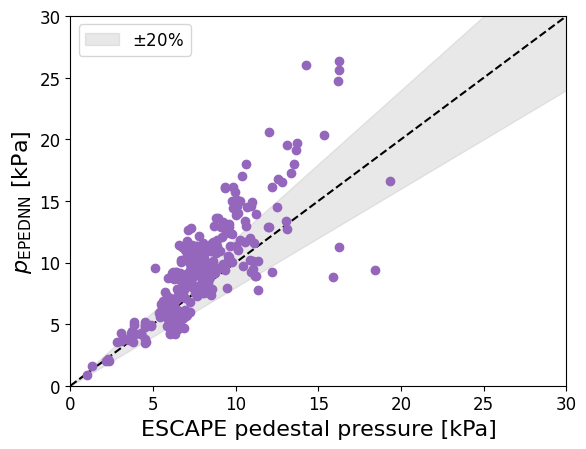

In [16]:
# ESCAPE pedestal pressure (x) vs EPEDNN pedestal pressure (y).
# Matched by equil tag (e.g. '125729.03589').
out_dir_EPEDNN_pure = (
    '/mnt/homes_global/jal2351/software/saarelma-conner-ped/tests/EPEDNN/'
    'EPEDNN_pure_output/'
)

# tag -> EPEDNN ped height [MPa]
eped_by_tag = {}
for entry in Path(out_dir_EPEDNN_pure).iterdir():
    if entry.suffix != '.npy':
        continue
    d = np.load(entry, allow_pickle=True).item()
    eped_by_tag[entry.stem] = float(d['pedestal_height'])

fig, ax = plt.subplots()
n_plot = 0
n_skip = 0
for entry in Path(out_dir).iterdir():
    target = entry / 'success_outdict.npy'
    if not target.exists():
        continue
    out_dict = np.load(target, allow_pickle=True).item()
    tag = entry.name
    if tag not in eped_by_tag:
        n_skip += 1
        continue
    p_escape = out_dict['ped_h'] * 1e3       # kPa  (x of ESCAPE-vs-IDA plot)
    p_epednn = eped_by_tag[tag] * 1e3        # kPa  (x of EPEDNN-vs-IDA plot)
    ax.plot(p_escape, p_epednn, 'o', color='tab:purple')
    n_plot += 1

x_line = np.linspace(0, 0.03 * 10**3, 200)
pm = 20
ax.fill_between(
    x_line, (1 - (pm / 100)) * x_line, (1 + (pm / 100)) * x_line,
    color='0.75', alpha=0.35, label=fr'$\pm {pm}\%$',
    zorder=0,
)
ax.plot(x_line, x_line, 'k--', zorder=1)
ax.set_xlabel('ESCAPE pedestal pressure [kPa]', **label_kw)
ax.set_ylabel(r'$p_{\mathrm{EPEDNN}}$ [kPa]', **label_kw)
ax.legend(loc='upper left', fontsize=tick_labelsize)
ax.tick_params('both', labelsize=tick_labelsize)
ax.set_xlim(0, 0.03 * 10**3)
ax.set_ylim(0, 0.03 * 10**3)
print(f'Plotted {n_plot} matched ESCAPE–EPEDNN pairs (skipped {n_skip} without EPEDNN result)')
